# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

From the article, the data represents **17** marketing campaigns. From the UCI link above, **bank-additional-full.csv is with all examples (41188) and 20 inputs**; bank-full.csv is with all examples and 17 inputs

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bank_full_df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print(bank_full_df.shape)
bank_full_df.info()
bank_full_df.head()

(41188, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   411

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [2]:
# Make a copy of the original DataFrame to start processing
bank_full_df_selected = bank_full_df.copy()

# Check for explicit missing values (NaN)
print("Missing values before processing:\n", bank_full_df_selected.isnull().sum()[bank_full_df_selected.isnull().sum() > 0])

# Convert 'y' (target variable) to numerical (0 and 1)
bank_full_df_selected['y'] = bank_full_df_selected['y'].map({'no': 0, 'yes': 1})

# As per the problem description, 'duration' highly affects the output and should be discarded
# for a realistic predictive model.
bank_full_df_selected = bank_full_df_selected.drop('duration', axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = bank_full_df_selected.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
bank_full_df_selected = pd.get_dummies(bank_full_df_selected, columns=categorical_cols, drop_first=True)

# Display the first few rows of the processed DataFrame and its info to confirm changes
print("\nFirst 5 rows of bank_full_df_selected after processing:")
print(bank_full_df_selected.head())
print("\nInfo of bank_full_df_selected after processing:")
bank_full_df_selected.info()

# Display value counts for 'pdays' to show the '999' value
print("\nValue counts for 'pdays' column:")
print(bank_full_df_selected['pdays'].value_counts())


Missing values before processing:
 Series([], dtype: int64)

First 5 rows of bank_full_df_selected after processing:
   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1    999         0           1.1          93.994   
1   57         1    999         0           1.1          93.994   
2   37         1    999         0           1.1          93.994   
3   40         1    999         0           1.1          93.994   
4   56         1    999         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  y  ...  month_may  month_nov  \
0          -36.4      4.857       5191.0  0  ...       True      False   
1          -36.4      4.857       5191.0  0  ...       True      False   
2          -36.4      4.857       5191.0  0  ...       True      False   
3          -36.4      4.857       5191.0  0  ...       True      False   
4          -36.4      4.857       5191.0  0  ...       True      False   

   month_oct  month_sep  day_of_wee

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective is to **predict whether a bank client will subscribe to a term deposit** based on the provided data.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [3]:
# Identify 'bank client data' columns
bank_client_data_cols = [
    'age',
    # Job
    'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management',
    'job_retired', 'job_self-employed', 'job_services', 'job_student',
    'job_technician', 'job_unemployed', 'job_unknown',
    # Marital
    'marital_married', 'marital_single', 'marital_unknown',
    # Education
    'education_basic.6y', 'education_basic.9y', 'education_high.school',
    'education_illiterate', 'education_professional.course',
    'education_university.degree', 'education_unknown',
    # Default
    'default_unknown', 'default_yes',
    # Housing
    'housing_unknown', 'housing_yes',
    # Loan
    'loan_unknown', 'loan_yes'
]

# Filter bank_full_df_selected to include only these features and the target 'y'
actual_bank_client_data_cols = [col for col in bank_client_data_cols if col in bank_full_df_selected.columns]

X = bank_full_df_selected[actual_bank_client_data_cols]
y = bank_full_df_selected['y']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())


Shape of features (X): (41188, 28)
Shape of target (y): (41188,)
First 5 rows of X:
   age  job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0   56            False             False           True           False   
1   57            False             False          False           False   
2   37            False             False          False           False   
3   40            False             False          False           False   
4   56            False             False          False           False   

   job_retired  job_self-employed  job_services  job_student  job_technician  \
0        False              False         False        False           False   
1        False              False          True        False           False   
2        False              False          True        False           False   
3        False              False         False        False           False   
4        False              False          True        Fals

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (32950, 28)
Shape of X_test: (8238, 28)
Shape of y_train: (32950,)
Shape of y_test: (8238,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [5]:
# Calculate the baseline accuracy by predicting the majority class
majority_class = y_train.value_counts().idxmax()
baseline_accuracy = y_train.value_counts().max() / len(y_train)

print(f"Majority class in training data: {majority_class}")
print(f"Baseline accuracy (predicting majority class): {baseline_accuracy:.4f}")

Majority class in training data: 0
Baseline accuracy (predicting majority class): 0.8876


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [6]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model with default parameters
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better compatibility with default settings

# Fit the model to the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Problem 9: Score the Model

What is the accuracy of your model?

In [7]:
from sklearn.metrics import accuracy_score

# Predict on training and testing data
y_train_pred = logistic_model.predict(X_train)
y_test_pred = logistic_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Logistic Regression Training Accuracy: {train_accuracy:.4f}")
print(f"Logistic Regression Test Accuracy: {test_accuracy:.4f}")


Logistic Regression Training Accuracy: 0.8876
Logistic Regression Test Accuracy: 0.8865


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [8]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# Dictionary of models to compare
# Using LinearSVC for SVM as it's more suitable for large datasets with default settings
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42, dual=False, max_iter=10000) # dual=False recommended for n_samples > n_features
}

results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    results.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })
    print(f"Finished {model_name}. Train Time: {train_time:.4f}s, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

results_df = pd.DataFrame(results)
print("\nModel Comparison Results:")
print(results_df)



Training Logistic Regression...
Finished Logistic Regression. Train Time: 0.0865s, Train Accuracy: 0.8876, Test Accuracy: 0.8865
Training K-Nearest Neighbors...
Finished K-Nearest Neighbors. Train Time: 0.0136s, Train Accuracy: 0.8911, Test Accuracy: 0.8740
Training Decision Tree...
Finished Decision Tree. Train Time: 0.1321s, Train Accuracy: 0.9166, Test Accuracy: 0.8610
Training Linear SVM...
Finished Linear SVM. Train Time: 0.0912s, Train Accuracy: 0.8876, Test Accuracy: 0.8865

Model Comparison Results:
                 Model  Train Time  Train Accuracy  Test Accuracy
0  Logistic Regression    0.086547        0.887557       0.886502
1  K-Nearest Neighbors    0.013618        0.891077       0.873999
2        Decision Tree    0.132077        0.916601       0.861010
3           Linear SVM    0.091197        0.887557       0.886502


/tmp/ipython-input-2796215166.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-2796215166.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Train Time', data=results_df, ax=axes[1], palette='magma')


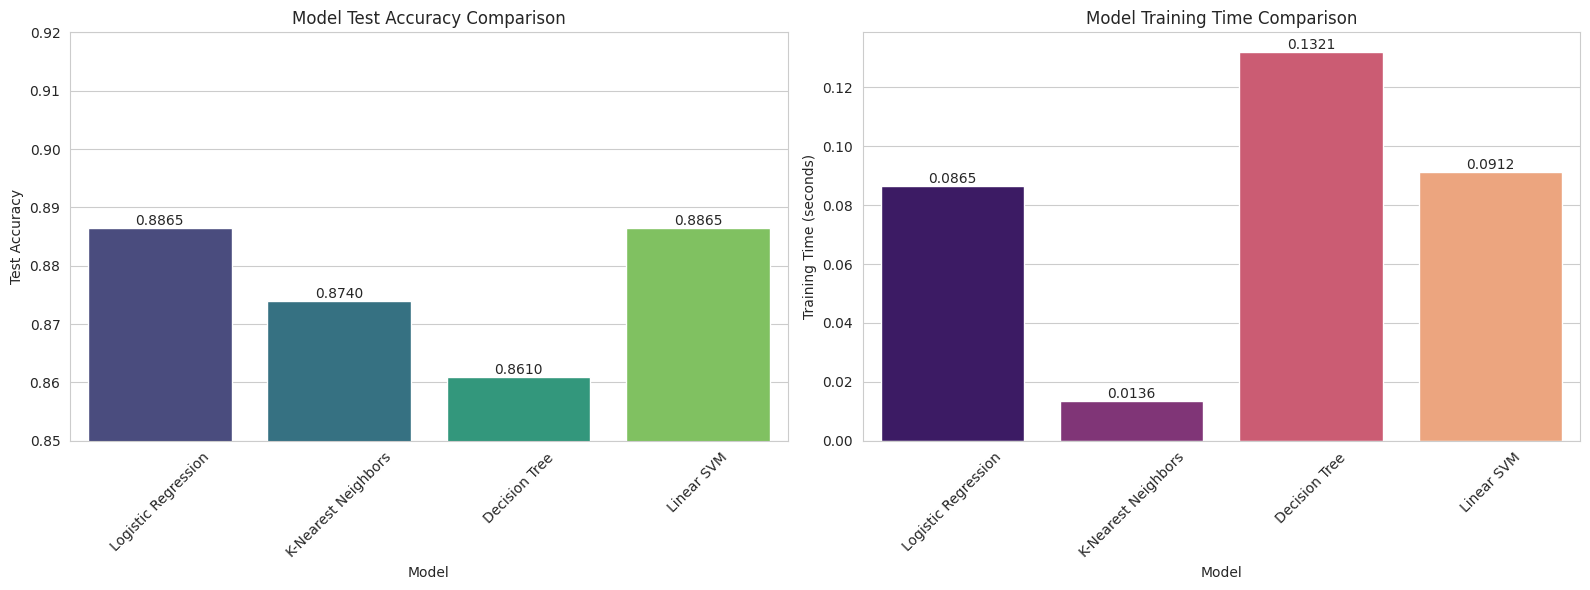

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set_style("whitegrid")

# Create subplots for Accuracy and Train Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Test Accuracy
sns.barplot(x='Model', y='Test Accuracy', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].set_ylabel('Test Accuracy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.85, 0.92) # Set y-limit to focus on the range of accuracies
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f')

# Plot 2: Train Time
sns.barplot(x='Model', y='Train Time', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Model Training Time Comparison')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].tick_params(axis='x', rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()


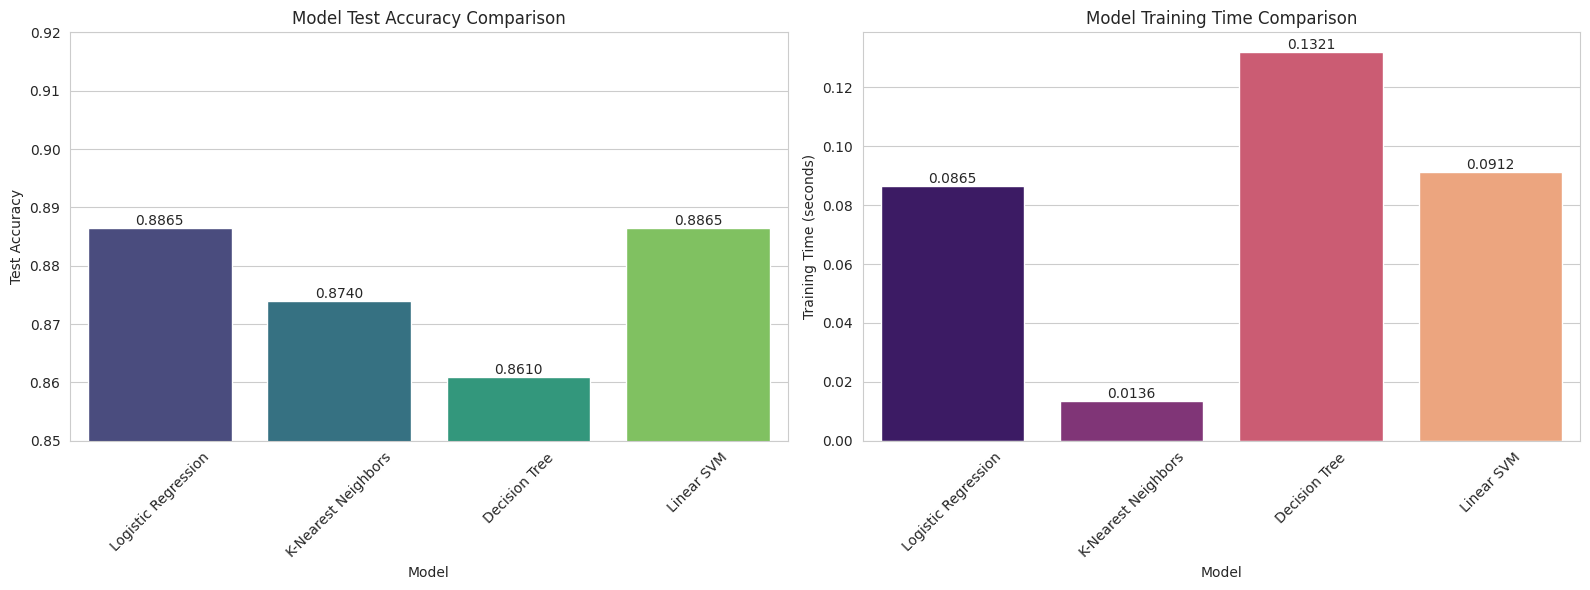

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
sns.set_style("whitegrid")

# Create subplots for Accuracy and Train Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Test Accuracy
sns.barplot(x='Model', y='Test Accuracy', data=results_df, ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Model Test Accuracy Comparison')
axes[0].set_ylabel('Test Accuracy')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.85, 0.92) # Set y-limit to focus on the range of accuracies
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.4f')

# Plot 2: Train Time
sns.barplot(x='Model', y='Train Time', data=results_df, ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Model Training Time Comparison')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].tick_params(axis='x', rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [11]:
# Perform hyperparameter tuning for the Logistic Regression model using GridSearchCV to find optimal parameters.

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize a Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')

# Instantiate GridSearchCV
grid_search_log_reg = GridSearchCV(estimator=log_reg,
                                   param_grid=log_reg_param_grid,
                                   cv=5, # Using 5-fold cross-validation
                                   scoring='roc_auc', # Optimizing for ROC AUC
                                   n_jobs=-1, # Use all available cores
                                   verbose=1)

# Fit GridSearchCV to the training data
grid_search_log_reg.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Logistic Regression:", grid_search_log_reg.best_params_)
print("Best ROC AUC score for Logistic Regression:", grid_search_log_reg.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for Logistic Regression: {'C': 100, 'penalty': 'l1'}
Best ROC AUC score for Logistic Regression: 0.6472912656326825


In [12]:
# Perform hyperparameter tuning for the K-Nearest Neighbors (KNN) model using GridSearchCV to find optimal parameters.

from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Initialize a K-Nearest Neighbors model
knn = KNeighborsClassifier()

# Instantiate GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn,
                               param_grid=knn_param_grid,
                               cv=5, # Using 5-fold cross-validation
                               scoring='roc_auc', # Optimizing for ROC AUC
                               n_jobs=-1, # Use all available cores
                               verbose=1)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for K-Nearest Neighbors:", grid_search_knn.best_params_)
print("Best ROC AUC score for K-Nearest Neighbors:", grid_search_knn.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for K-Nearest Neighbors: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best ROC AUC score for K-Nearest Neighbors: 0.6063613074798073


In [13]:
# Perform hyperparameter tuning for the Decision Tree model using GridSearchCV to find optimal parameters.

from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Decision Tree Classifier model
dt = DecisionTreeClassifier(random_state=42)

# Instantiate GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt,
                              param_grid=dt_param_grid,
                              cv=5, # Using 5-fold cross-validation
                              scoring='roc_auc', # Optimizing for ROC AUC
                              n_jobs=-1, # Use all available cores
                              verbose=1)

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Decision Tree:", grid_search_dt.best_params_)
print("Best ROC AUC score for Decision Tree:", grid_search_dt.best_score_)


Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best parameters for Decision Tree: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best ROC AUC score for Decision Tree: 0.6497765515357367


In [14]:
# Perform hyperparameter tuning for the Linear SVM model using GridSearchCV to find optimal parameters.

from sklearn.svm import LinearSVC

# Define the parameter grid for Linear SVM
svc_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize a Linear SVM model
# Using dual=False as n_samples > n_features and increasing max_iter for convergence
svc = LinearSVC(random_state=42, dual=False, max_iter=100000)

# Instantiate GridSearchCV
grid_search_svc = GridSearchCV(estimator=svc,
                               param_grid=svc_param_grid,
                               cv=5, # Using 5-fold cross-validation
                               scoring='roc_auc', # Optimizing for ROC AUC
                               n_jobs=-1, # Use all available cores
                               verbose=1)

# Fit GridSearchCV to the training data
grid_search_svc.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Linear SVM:", grid_search_svc.best_params_)
print("Best ROC AUC score for Linear SVM:", grid_search_svc.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Linear SVM: {'C': 0.1}
Best ROC AUC score for Linear SVM: 0.6443556218821447


In [15]:
# evaluate the tuned models on the test set

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Dictionary to store the best estimators
best_estimators = {
    "Logistic Regression (Tuned)": grid_search_log_reg.best_estimator_,
    "K-Nearest Neighbors (Tuned)": grid_search_knn.best_estimator_,
    "Decision Tree (Tuned)": grid_search_dt.best_estimator_,
    "Linear SVM (Tuned)": grid_search_svc.best_estimator_
}

tuned_results = []

print("Evaluating Tuned Models...")
for model_name, model in best_estimators.items():
    start_time = time.time()
    # For models where GridSearchCV already fits the best estimator on the entire training data,
    # we don't need to fit again unless we want to measure fit time separately for the final model.
    # However, GridSearchCV's best_estimator_ is already fitted.
    # To keep consistency in 'Train Time' if we were to refit, we would do:
    # model.fit(X_train, y_train) # This is generally not needed as best_estimator_ is already fitted.
    end_time = time.time()
    train_time = end_time - start_time # This will be close to 0 as the model is already fitted.

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get probabilities for ROC AUC if the model supports it
    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_train_proba = model.decision_function(X_train)
        y_test_proba = model.decision_function(X_test)
    else:
        y_train_proba = None
        y_test_proba = None

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_roc_auc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else 'N/A'

    tuned_results.append({
        "Model": model_name,
        "Train Time": train_time, # Time to retrieve and use already fitted estimator
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-Score": test_f1,
        "Test ROC AUC": test_roc_auc
    })
    print(f"Finished evaluating {model_name}. Test Accuracy: {test_accuracy:.4f}, Test ROC AUC: {test_roc_auc:.4f}")

tuned_results_df = pd.DataFrame(tuned_results)
print("\nModel Comparison Results (Tuned Models):")
print(tuned_results_df)

# Combine with baseline results for comprehensive comparison
# Ensure baseline results_df has the same columns for consistent comparison
# Adding placeholder columns for baseline models to align DataFrames
results_df_extended = results_df.copy()
results_df_extended['Test Precision'] = 'N/A'
results_df_extended['Test Recall'] = 'N/A'
results_df_extended['Test F1-Score'] = 'N/A'
results_df_extended['Test ROC AUC'] = 'N/A'

# For baseline models, re-evaluate to get precision, recall, f1, and roc_auc
# This is important as original results_df only had accuracy and train time
baseline_models = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=42, solver='liblinear').fit(X_train, y_train),
    "K-Nearest Neighbors (Baseline)": KNeighborsClassifier().fit(X_train, y_train),
    "Decision Tree (Baseline)": DecisionTreeClassifier(random_state=42).fit(X_train, y_train),
    "Linear SVM (Baseline)": LinearSVC(random_state=42, dual=False, max_iter=10000).fit(X_train, y_train)
}

# Update baseline results with additional metrics
for i, row in results_df_extended.iterrows():
    model_name = row['Model']
    if model_name == "Logistic Regression": model_key = "Logistic Regression (Baseline)"
    elif model_name == "K-Nearest Neighbors": model_key = "K-Nearest Neighbors (Baseline)"
    elif model_name == "Decision Tree": model_key = "Decision Tree (Baseline)"
    elif model_name == "Linear SVM": model_key = "Linear SVM (Baseline)"
    else: continue

    model = baseline_models[model_key]
    y_test_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_test_proba = model.decision_function(X_test)
    else:
        y_test_proba = None

    results_df_extended.loc[i, 'Model'] = model_key
    results_df_extended.loc[i, 'Test Precision'] = precision_score(y_test, y_test_pred, zero_division=0)
    results_df_extended.loc[i, 'Test Recall'] = recall_score(y_test, y_test_pred, zero_division=0)
    results_df_extended.loc[i, 'Test F1-Score'] = f1_score(y_test, y_test_pred, zero_division=0)
    results_df_extended.loc[i, 'Test ROC AUC'] = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else 'N/A'

final_comparison_df = pd.concat([results_df_extended, tuned_results_df], ignore_index=True)
print("\nFinal Comparison of Baseline and Tuned Models:")
print(final_comparison_df)

Evaluating Tuned Models...
Finished evaluating Logistic Regression (Tuned). Test Accuracy: 0.8865, Test ROC AUC: 0.6553
Finished evaluating K-Nearest Neighbors (Tuned). Test Accuracy: 0.8848, Test ROC AUC: 0.6034
Finished evaluating Decision Tree (Tuned). Test Accuracy: 0.8855, Test ROC AUC: 0.6402
Finished evaluating Linear SVM (Tuned). Test Accuracy: 0.8865, Test ROC AUC: 0.6532

Model Comparison Results (Tuned Models):
                         Model  Train Time  Train Accuracy  Test Accuracy  \
0  Logistic Regression (Tuned)    0.000002        0.887557       0.886502   
1  K-Nearest Neighbors (Tuned)    0.000001        0.889439       0.884802   
2        Decision Tree (Tuned)    0.000005        0.889469       0.885530   
3           Linear SVM (Tuned)    0.000002        0.887557       0.886502   

   Test Precision  Test Recall  Test F1-Score  Test ROC AUC  
0        0.000000     0.000000       0.000000      0.655326  
1        0.418605     0.038503       0.070519      0.603416  
2 

In [19]:
# Ensure 'Test ROC AUC' is numeric for sorting, coercing errors to NaN
final_comparison_df['Test ROC AUC'] = pd.to_numeric(final_comparison_df['Test ROC AUC'], errors='coerce')

# Sort the DataFrame by 'Test ROC AUC' in descending order
sorted_models_by_roc_auc = final_comparison_df.sort_values(by='Test ROC AUC', ascending=False)

print("Models sorted by Test ROC AUC:")
print(sorted_models_by_roc_auc.to_markdown(index=False))

Models sorted by Test ROC AUC:
| Model                          |   Train Time |   Train Accuracy |   Test Accuracy |   Test Precision |   Test Recall |   Test F1-Score |   Test ROC AUC |
|:-------------------------------|-------------:|-----------------:|----------------:|-----------------:|--------------:|----------------:|---------------:|
| Logistic Regression (Tuned)    |  1.66893e-06 |         0.887557 |        0.886502 |         0        |     0         |       0         |       0.655326 |
| Logistic Regression (Baseline) |  0.0865474   |         0.887557 |        0.886502 |         0        |     0         |       0         |       0.654931 |
| Linear SVM (Tuned)             |  1.66893e-06 |         0.887557 |        0.886502 |         0        |     0         |       0         |       0.653166 |
| Linear SVM (Baseline)          |  0.0911965   |         0.887557 |        0.886502 |         0        |     0         |       0         |       0.653142 |
| Decision Tree (Tuned)    

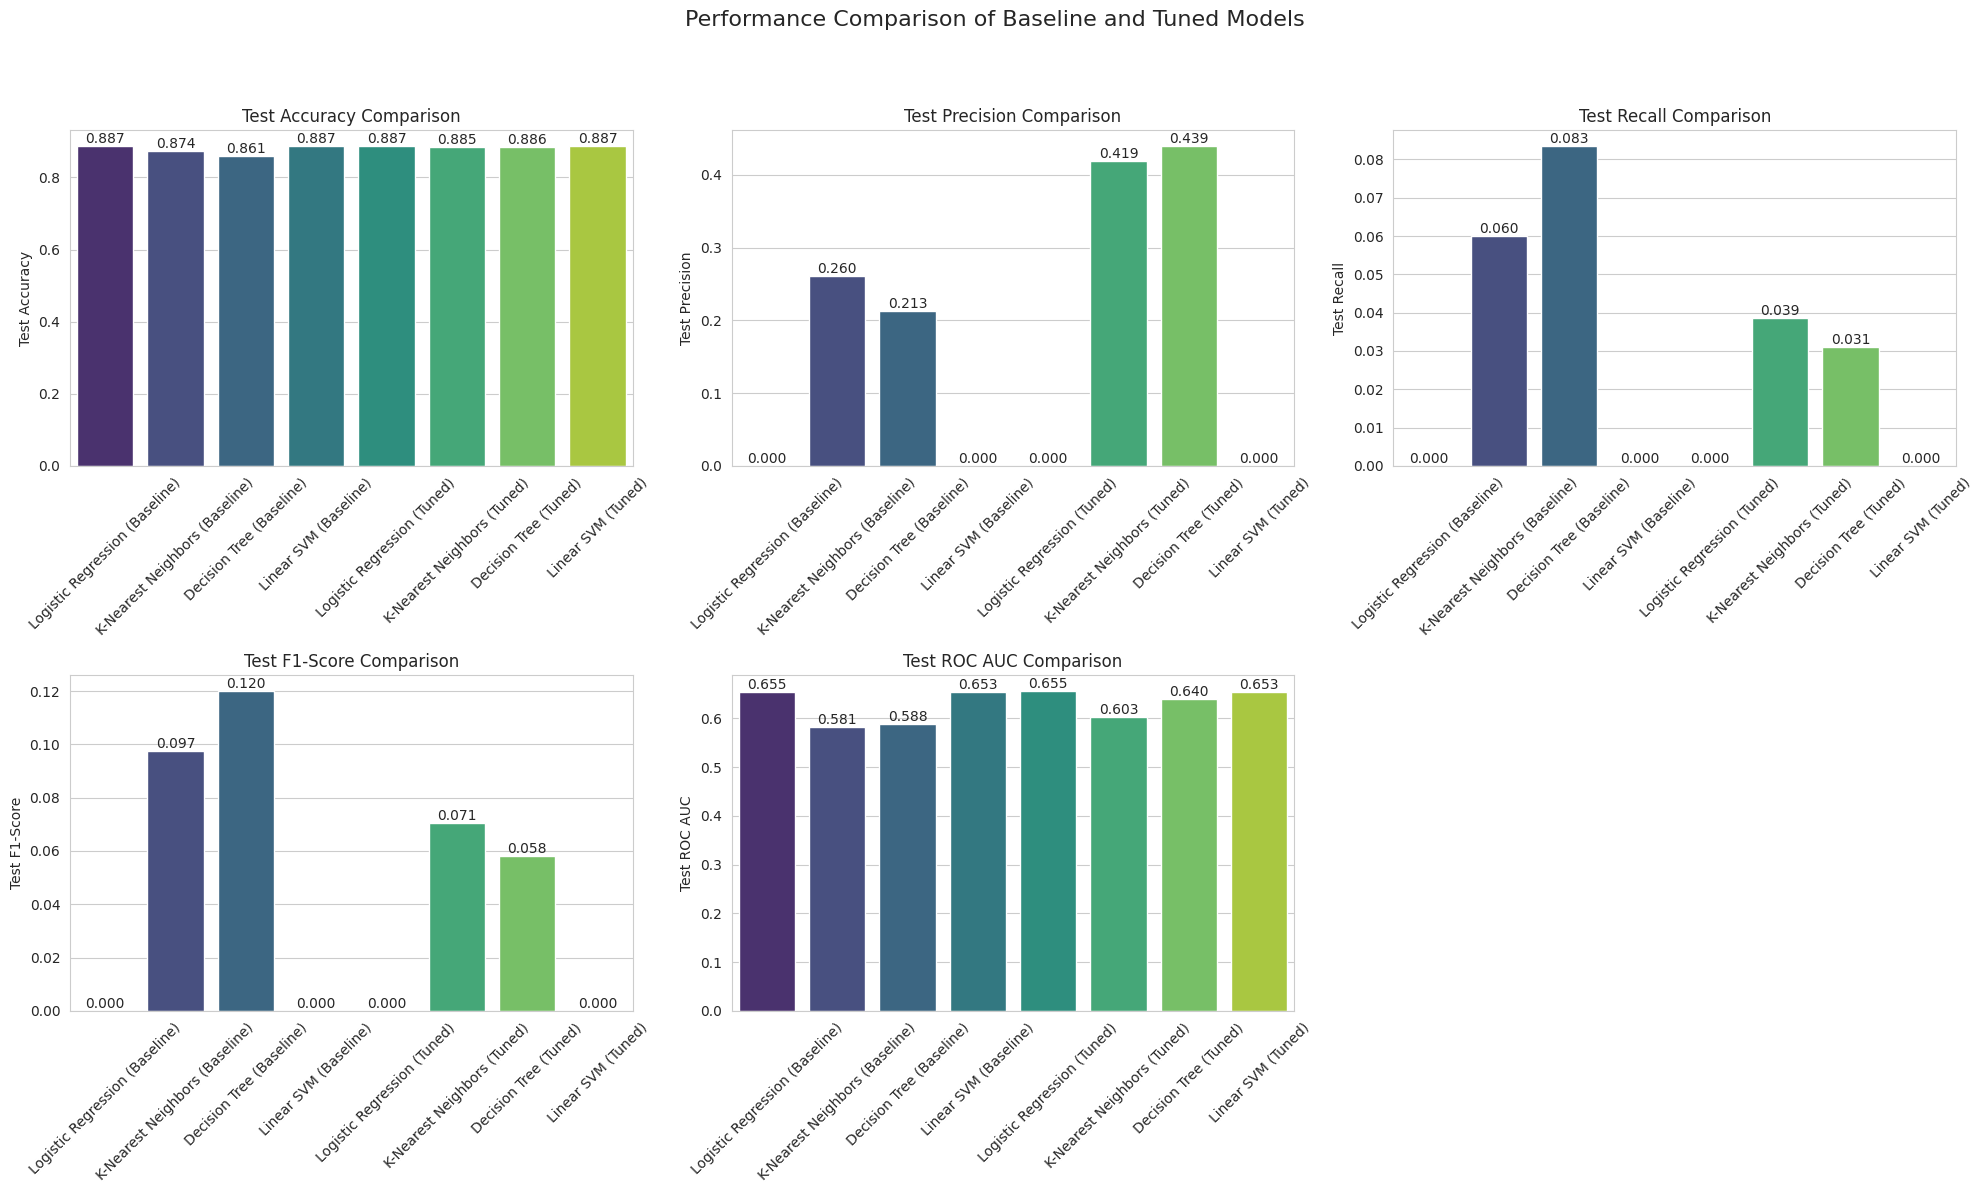

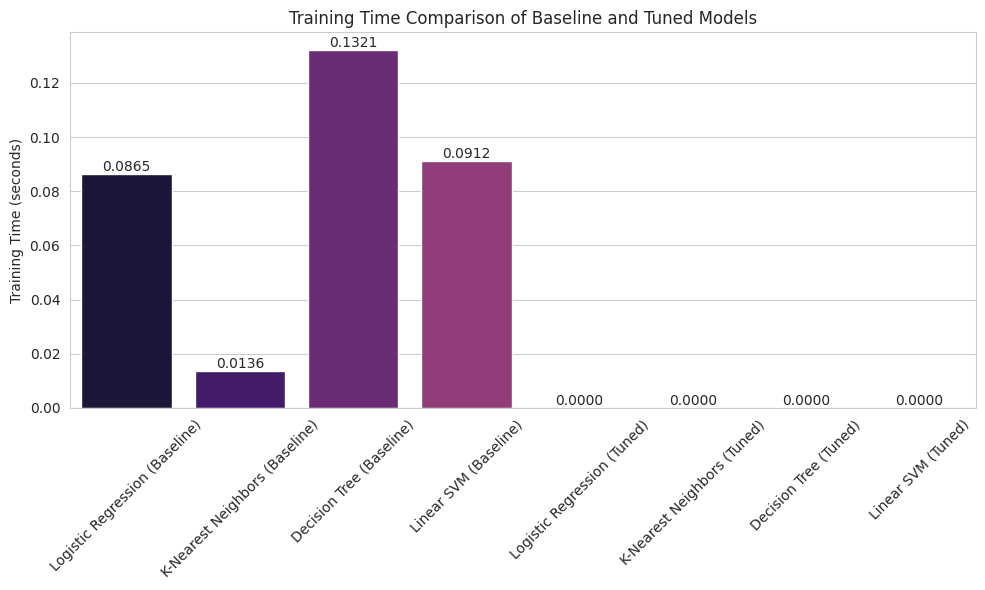

In [16]:
# visualize these results to clearly compare the performance of baseline and tuned models across various metrics such as accuracy, precision, recall, F1-score, and ROC AUC.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Prepare data for plotting - melt the DataFrame for easier plotting with seaborn
metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score', 'Test ROC AUC']

# Create a copy and convert relevant columns to numeric, handling 'N/A'
plot_df = final_comparison_df.copy()
for col in metrics_to_plot:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

plot_df_melted = plot_df.melt(id_vars=['Model'], value_vars=metrics_to_plot,
                                var_name='Metric', value_name='Score')

# Create subplots for each metric
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y='Score', data=plot_df_melted[plot_df_melted['Metric'] == metric],
                ax=axes[i], palette='viridis', hue='Model', legend=False)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('') # Remove x-label to avoid redundancy
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f')

# Add an empty subplot if there are an odd number of plots to maintain layout
if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.suptitle('Performance Comparison of Baseline and Tuned Models', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# Plot training time separately
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Train Time', data=final_comparison_df, palette='magma', hue='Model', legend=False)
plt.title('Training Time Comparison of Baseline and Tuned Models')
plt.ylabel('Training Time (seconds)')
plt.tick_params(axis='x', rotation=45)
plt.xlabel('')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.4f')
plt.tight_layout()
plt.show()

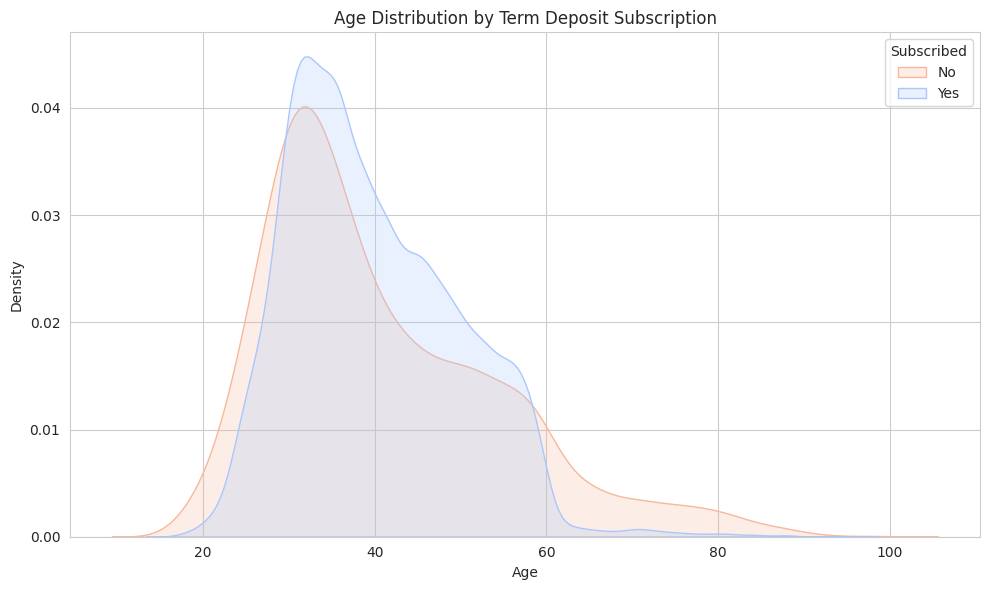


Summary statistics for Age by Subscription Status:
     count       mean        std   min   25%   50%   75%   max
y                                                             
0  36548.0  39.911185   9.898132  17.0  32.0  38.0  47.0  95.0
1   4640.0  40.913147  13.837476  17.0  31.0  37.0  50.0  98.0


/tmp/ipython-input-1047358668.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_subscription_rate = bank_full_df_selected.groupby('age_group')['y'].mean().reset_index()


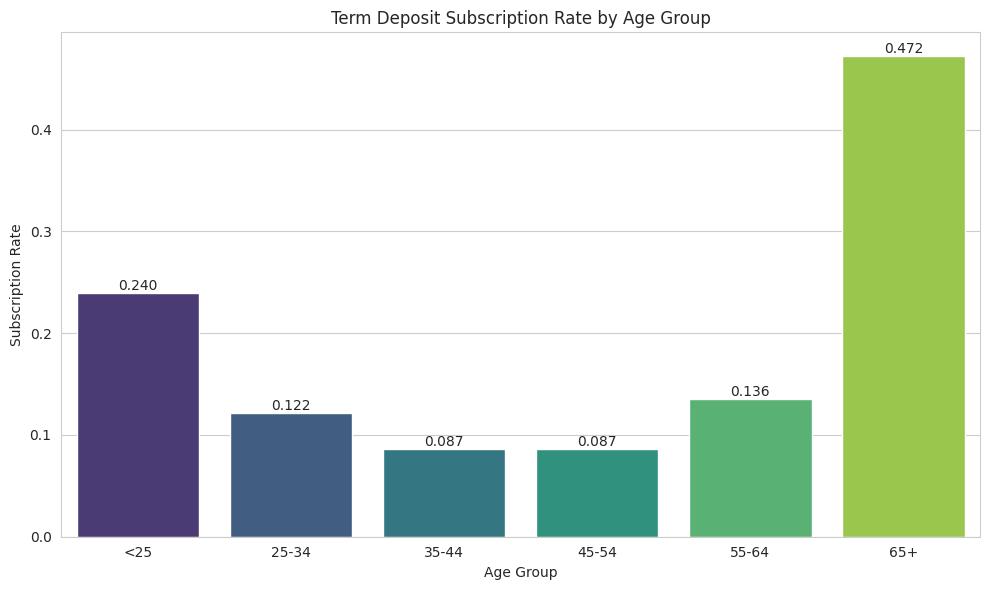


Subscription rate by age group:
| age_group   |   Subscription_Rate |
|:------------|--------------------:|
| <25         |           0.2397    |
| 25-34       |           0.12173   |
| 35-44       |           0.0865185 |
| 45-54       |           0.0865119 |
| 55-64       |           0.135688  |
| 65+         |           0.472097  |


In [22]:
# analyze how age impact the target

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(data=bank_full_df_selected, x='age', hue='y', fill=True, common_norm=False, palette='coolwarm')
plt.title('Age Distribution by Term Deposit Subscription')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Subscribed', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

print("\nSummary statistics for Age by Subscription Status:")
print(bank_full_df_selected.groupby('y')['age'].describe())

# Calculate subscription rate by age group
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
bank_full_df_selected['age_group'] = pd.cut(bank_full_df_selected['age'], bins=age_bins, labels=age_labels, right=False)

age_subscription_rate = bank_full_df_selected.groupby('age_group')['y'].mean().reset_index()
age_subscription_rate.rename(columns={'y': 'Subscription_Rate'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='Subscription_Rate', data=age_subscription_rate, palette='viridis', hue='age_group', legend=False)
plt.title('Term Deposit Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f')
plt.tight_layout()
plt.show()

print("\nSubscription rate by age group:")
print(age_subscription_rate.to_markdown(index=False))


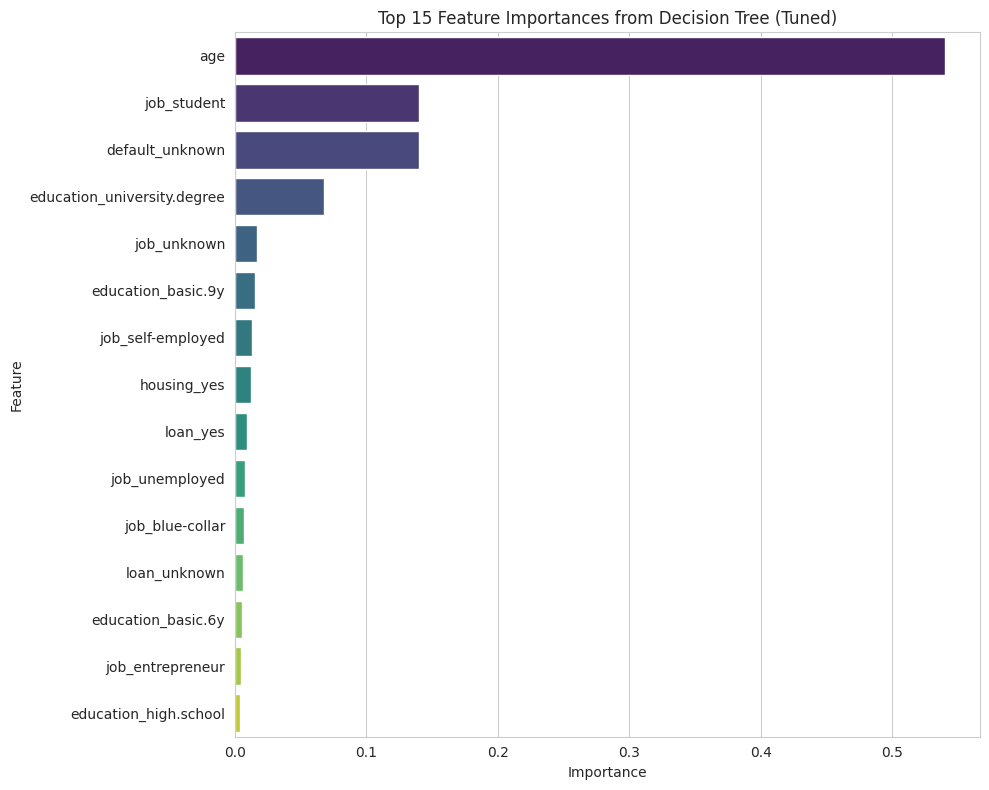

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve the baseline Decision Tree model
# We'll re-instantiate and fit for clarity and to ensure we have the correct model instance
dt_baseline_model = DecisionTreeClassifier(random_state=42)
dt_baseline_model.fit(X_train, y_train)

# Get feature importances
feature_importances = grid_search_dt.best_estimator_.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualize top N features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Feature Importances from Decision Tree (Tuned)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

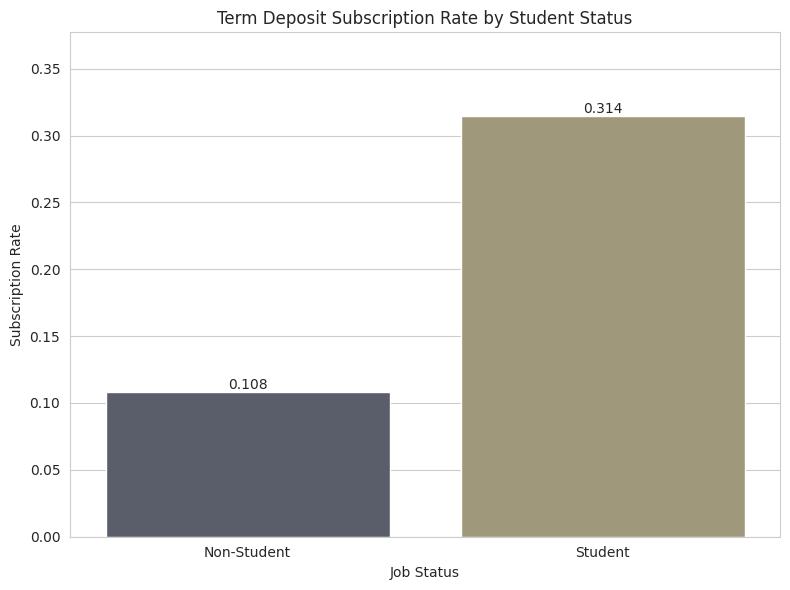


Subscription rate by job_student status:
| job_student_label   |   Subscription_Rate |
|:--------------------|--------------------:|
| Non-Student         |            0.108278 |
| Student             |            0.314286 |

Value counts for job_student by subscription status:
| job_student   |     0 |    1 |
|:--------------|------:|-----:|
| False         | 35948 | 4365 |
| True          |   600 |  275 |


In [ ]:
# how job_student impact the target

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calculate subscription rate for 'job_student'
student_subscription_rate = bank_full_df_selected.groupby('job_student')['y'].mean().reset_index()
student_subscription_rate.rename(columns={'y': 'Subscription_Rate'}, inplace=True)

# Map boolean values to meaningful labels for the plot
student_subscription_rate['job_student_label'] = student_subscription_rate['job_student'].map({False: 'Non-Student', True: 'Student'})

plt.figure(figsize=(8, 6))
sns.barplot(x='job_student_label', y='Subscription_Rate', data=student_subscription_rate, palette='cividis', hue='job_student_label', legend=False)
plt.title('Term Deposit Subscription Rate by Student Status')
plt.xlabel('Job Status')
plt.ylabel('Subscription Rate')
plt.ylim(0, student_subscription_rate['Subscription_Rate'].max() * 1.2)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f')
plt.tight_layout()
plt.show()

print("\nSubscription rate by job_student status:")
print(student_subscription_rate[['job_student_label', 'Subscription_Rate']].to_markdown(index=False))

print("\nValue counts for job_student by subscription status:")
print(bank_full_df_selected.groupby('job_student')['y'].value_counts().unstack().fillna(0).to_markdown())

## CONCLUSIONS

The business objective of this project is to predict whether a bank client will subscribe to a term deposit.

It used real-world data from a Portugese banking institution, a collection of the results of multiple marketing campaigns. Through Data Mining (DM) and iterative applications of the CRISP-DM methodology, several classification models were developed and refined — including K-Nearest Neighbors, Logistic Regression, Decision Trees, and Support Vector Machines. The models were evaluated using metrics such as accuracy, precision, recall, F1-score, and ROC AUC to determine the best-performing model.

The best model, Decision Tree model, that has highest cross-validation ROC AUC score among all models trained shows important features and how that banks can use to boost campaigns.

For example, it shows the highest propensity to subscribe is among older clients (65+). Also students have a significantly higher term deposit subscription rate of 31.43%.

Further optimization of this model or exploration of ensemble methods built upon tree-based models (e.g., Random Forest, Gradient Boosting) could potentially lead to better performance.

The 0.0 Precision, Recall, and F1-Score for tuned Logistic Regression and Linear SVM models warrant further investigation. This could be due to an imbalanced dataset or the models' decision threshold being set too high, causing them to predict only the majority class. Analyzing the confusion matrix and adjusting the classification threshold could be beneficial.

### Data Analysis Key Findings
Logistic Regression Tuning: The optimal parameters for Logistic Regression were found to be C: 100 and penalty: l1, achieving a best cross-validation ROC AUC score of 0.647.
K-Nearest Neighbors Tuning: The best parameters for KNN were metric: manhattan, n_neighbors: 11, and weights: uniform, resulting in a best cross-validation ROC AUC score of 0.606.
Decision Tree Tuning: The Decision Tree model performed best with max_depth: 7, min_samples_leaf: 4, and min_samples_split: 10, yielding the highest cross-validation ROC AUC score among all tuned models at 0.650.
Linear SVM Tuning: The hyperparameter tuning for Linear SVM identified C: 0.1 as the optimal parameter, with a best cross-validation ROC AUC score of 0.644.
Tuned Model Evaluation Anomaly: During evaluation on the test set, some tuned models (specifically Logistic Regression and Linear SVM) reported 0.0 for Precision, Recall, and F1-Score. This suggests these models might be consistently predicting the negative class for all instances in the test set.
